Plotted JSON files:
  - cifar10_variants_eval_ckpt-R2-adv-test_seed-1_inpP-inf_eps-0p0039_steps-20_restarts-5_natural-0.json
  - cifar10_variants_eval_ckpt-R2-adv-test_seed-1_inpP-inf_eps-0p007_steps-20_restarts-5_natural-0.json
  - cifar10_variants_eval_ckpt-R2-adv-test_seed-1_inpP-inf_eps-0p015_steps-20_restarts-5_natural-0.json
  - cifar10_variants_eval_ckpt-R2-adv-test_seed-1_inpP-inf_eps-0p023_steps-20_restarts-5_natural-0.json
  - cifar10_variants_eval_ckpt-R2-adv-test_seed-1_inpP-inf_eps-0p031_steps-20_restarts-5_natural-0.json
  - cifar10_variants_eval_ckpt-R2-adv-test_seed-1_inpP-inf_eps-0p039_steps-20_restarts-5_natural-0.json
  - cifar10_variants_eval_ckpt-R2-adv-test_seed-1_inpP-inf_eps-0p047_steps-20_restarts-5_natural-0.json
Figure saved to: /mnt/lts4/scratch/students/aabdolla/LAT/figures/robust_vs_epsilon_R2.pdf


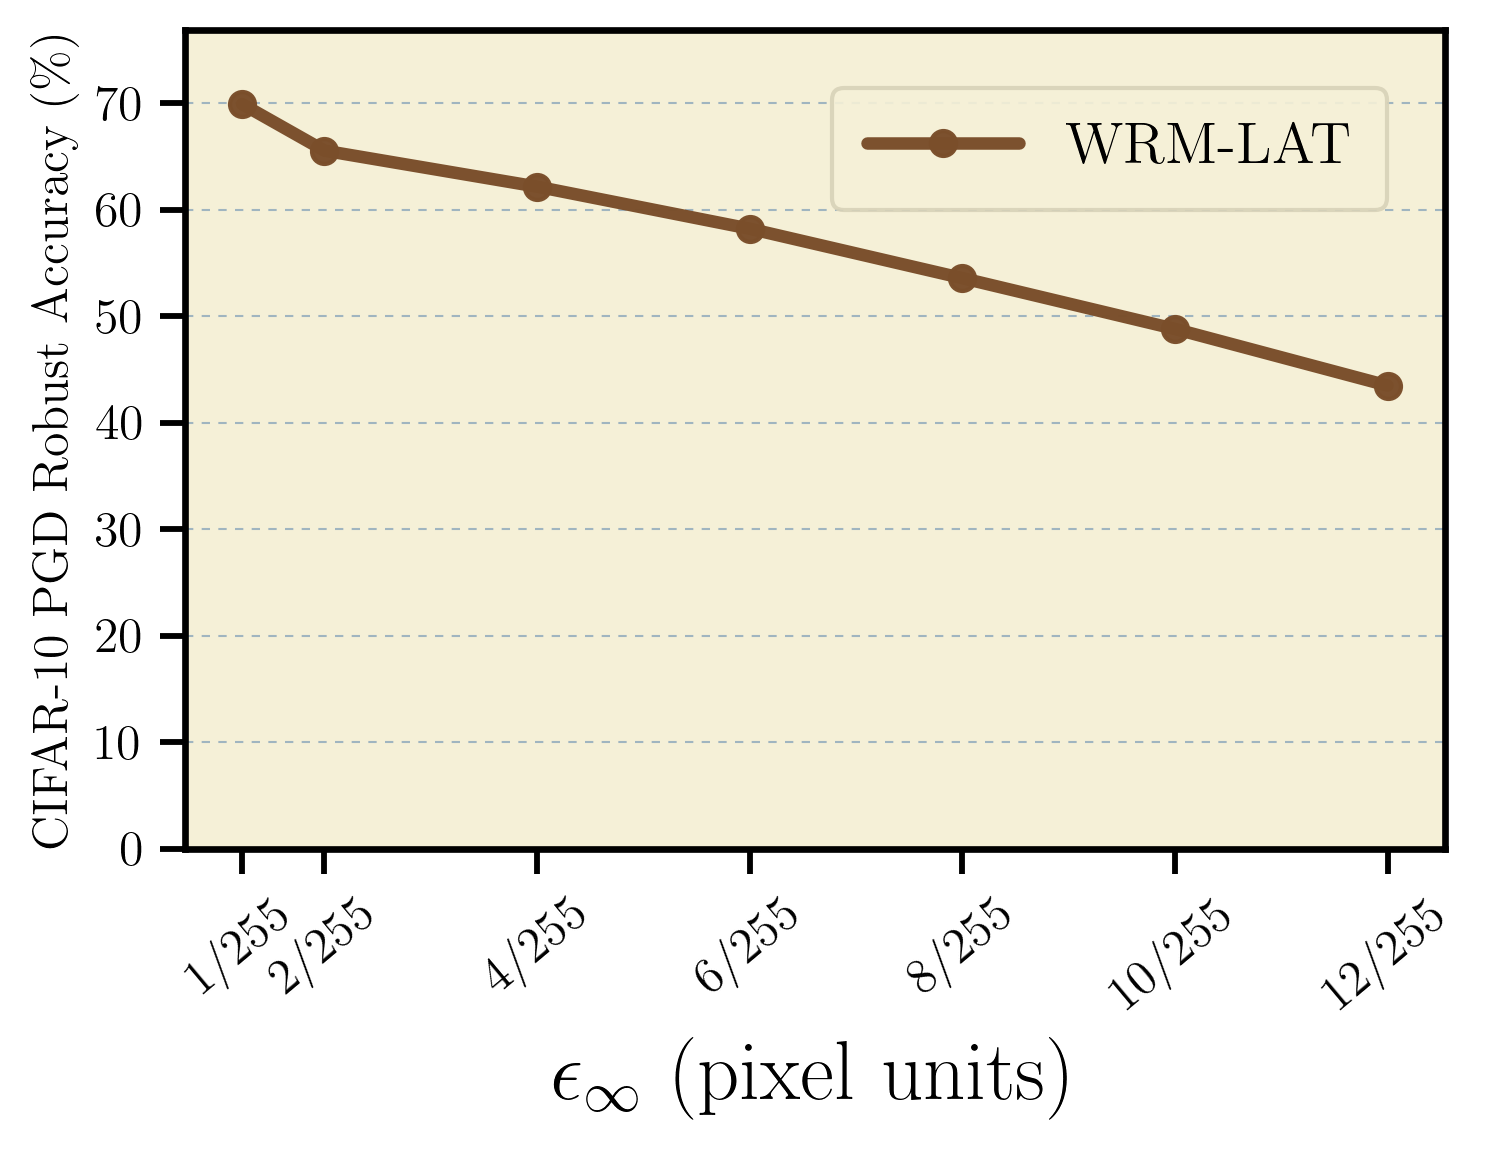

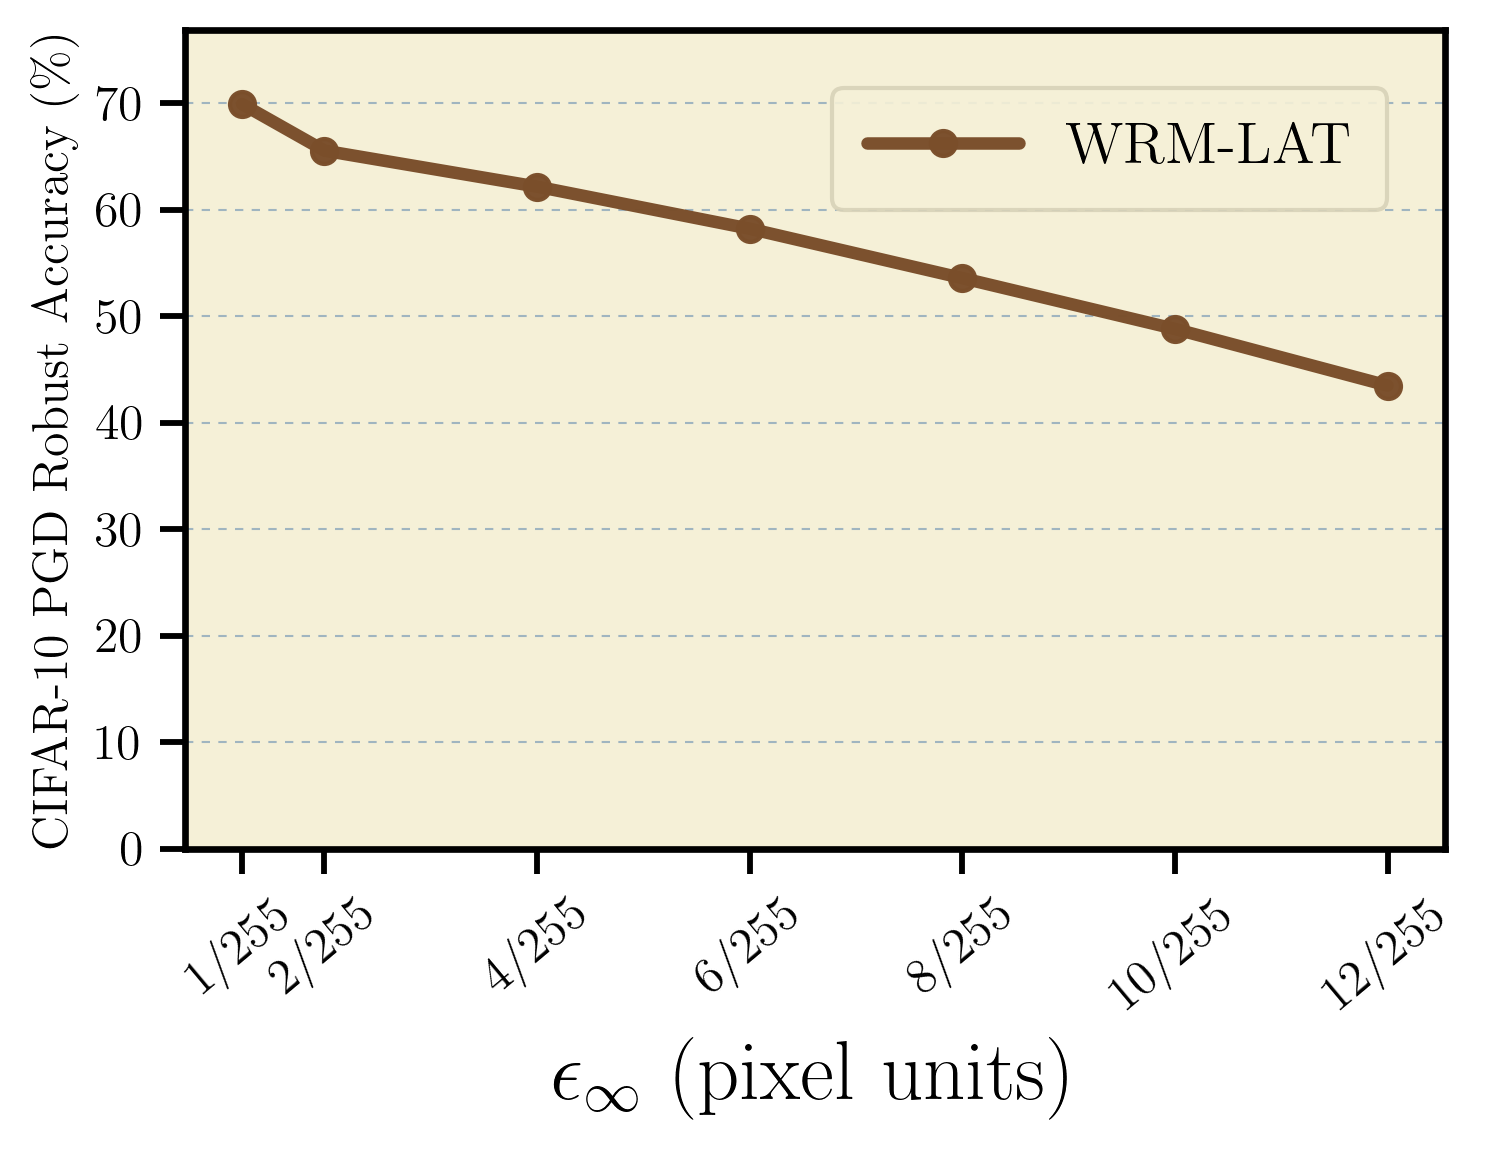

In [7]:
from pathlib import Path
import json
import numpy as np

from plot_template import set_paper_style, styled_axes, plot_series, add_legend

# Apply the shared plotting style
set_paper_style()

# Look for the evaluation JSON files in the current directory
base_dir = Path.cwd()
json_paths = sorted(base_dir.glob("cifar10_variants_eval_*.json"))
if not json_paths:
    raise FileNotFoundError(f"No evaluation JSON files found in {base_dir.resolve()}")

eps_values = []
robust_values = []
source_files = []

# Extract epsilon and robust accuracy from each JSON file
for path in json_paths:
    with path.open("r") as f:
        data = json.load(f)

    pgd_params = data.get("scores", {}).get("pgd_params")
    cifar10_pgd = data.get("scores", {}).get("cifar10_pgd")
    if pgd_params is None or cifar10_pgd is None:
        continue  # skip files missing the PGD block

    eps_values.append(float(pgd_params["eps"]))
    robust_values.append(float(cifar10_pgd["acc"]))
    source_files.append(path.name)

if not eps_values:
    raise ValueError("No PGD metrics with epsilon found in the JSON files.")

# Sort the results by epsilon
order = np.argsort(eps_values)
eps_values = np.array(eps_values)[order]
robust_values = np.array(robust_values)[order]
source_files = np.array(source_files)[order]

# Build the plot with the template helpers
fig, ax = styled_axes()
ax.set_xlabel(r"$\epsilon_{\infty}$ (pixel units)")
ax.set_ylabel("CIFAR-10 PGD Robust Accuracy (\%)")

plot_series(ax, eps_values, robust_values, label="WRM-LAT", color_key="mars", marker="o")
ax.set_xticks(eps_values)
ax.set_xticklabels([f"{int(round(eps * 255))}/255" for eps in eps_values], rotation=40)
ax.set_ylim(0, max(robust_values.max() * 1.1, 5))

# control the fontsize of the y-axis and x-axis name (not the tick labels)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(12)


# delete the right and top spines for a cleaner look
# ax.spines["right"].set_visible(False)
# ax.spines["top"].set_visible(False)

add_legend(ax)

# Save the figure to LAT/figures/robust_vs_epsilon.png
output_dir = base_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
figure_path = output_dir / "robust_vs_epsilon_R2.pdf"
fig.savefig(figure_path, bbox_inches="tight", dpi=300)

print("Plotted JSON files:")
for fname in source_files:
    print("  -", fname)

print("Figure saved to:", figure_path)

# Display the figure in the notebook
fig
